In [ ]:
import sys
import os
import torch
from transformers import AutoProcessor, AutoTokenizer

In [2]:
module_path = "/home/ubuntu/VLA-FYP/train/stage2/models"

In [3]:
if module_path not in sys.path:
    sys.path.append(module_path)

In [4]:
from latent_student import LatentStudent
from verbalizer import Verbalizer

In [5]:
import safetensors.torch as st
from peft import set_peft_model_state_dict

In [6]:
ckpt_dir = "/home/ubuntu/VLA-FYP/train/stage2/checkpoints/stage2/step_000300"

In [7]:
processor = AutoProcessor.from_pretrained("shreethar/stage1_unsloth")

In [8]:
# Fetch the </think> token ID from the tokenizer
end_think_id = processor.tokenizer.convert_tokens_to_ids("</think>")
if end_think_id is None or end_think_id == processor.tokenizer.unk_token_id:
    # Fallback if it's not a single mapped token
    end_think_id = processor.tokenizer.encode("</think>", add_special_tokens=False)[-1]

# Pass the ID when initializing LatentStudent
student = LatentStudent(
    model_name="shreethar/stage1_unsloth",
    end_think_token_id=end_think_id
)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [9]:
student.to("cuda")

batch_size = 1
seq_len = 64
device = next(student.parameters()).device

## Test with textual input (prompt)

In [14]:
prompt = (
    "You are a robot manipulation assistant. "
    "Given an observation image and a task instruction, predict the "
    "end-effector's 2D trajectory as 5 "
    "distinct waypoints showing the continuous movement from the start to the target. "
    "If reasoning, provide a single concise plan: identify the start, locate the target, "
    "and interpolate the path. Do NOT loop, endlessly refine, or re-evaluate. "
    "Once you get a feasible trajectory output, finish reasoning, DO NOT RE-EVALUATE."
    "Finally, output the coordinate list exactly once in this exact format: "
    "[[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]")

In [15]:
from PIL import Image

In [16]:
image = Image.open("image.jpg")

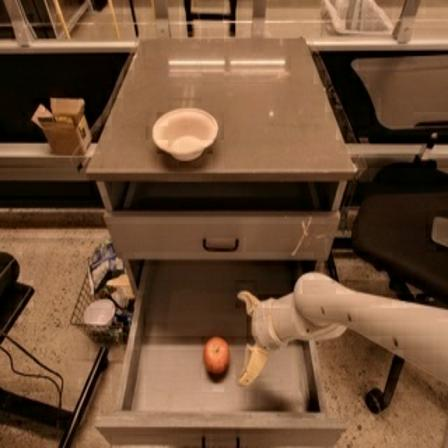

In [17]:
image

In [18]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

In [22]:
# Apply chat template to get the raw string
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict = True).to("cuda")

In [20]:
inputs.input_ids.shape

torch.Size([1, 344])

In [16]:
# Apply chat template to get the raw string
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,)
print(f"\n📝 Generated Prompt:\n{text}")


📝 Generated Prompt:
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>You are a robot manipulation assistant. Given an observation image and a task instruction, predict the end-effector's 2D trajectory as 5 distinct waypoints showing the continuous movement from the start to the target. If reasoning, provide a single concise plan: identify the start, locate the target, and interpolate the path. Do NOT loop, endlessly refine, or re-evaluate. Once you get a feasible trajectory output, finish reasoning, DO NOT RE-EVALUATE.Finally, output the coordinate list exactly once in this exact format: [[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]<|im_end|>
<|im_start|>assistant
<think>

</think>




In [17]:
# Apply chat template to get the raw string
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict = True).to("cuda")

In [18]:
student.vlm.model.model.language_model

Qwen3_5TextModel(
  (embed_tokens): Embedding(248320, 2560)
  (layers): ModuleList(
    (0-2): 3 x Qwen3_5DecoderLayer(
      (linear_attn): Qwen3_5GatedDeltaNet(
        (act): SiLUActivation()
        (conv1d): Conv1d(8192, 8192, kernel_size=(4,), stride=(1,), padding=(3,), groups=8192, bias=False)
        (norm): FusedRMSNormGated(128, eps=1e-06, activation=silu)
        (out_proj): lora.Linear(
          (base_layer): Linear(in_features=4096, out_features=2560, bias=False)
          (lora_dropout): ModuleDict(
            (default): Dropout(p=0.05, inplace=False)
          )
          (lora_A): ModuleDict(
            (default): Linear(in_features=4096, out_features=64, bias=False)
          )
          (lora_B): ModuleDict(
            (default): Linear(in_features=64, out_features=2560, bias=False)
          )
          (lora_embedding_A): ParameterDict()
          (lora_embedding_B): ParameterDict()
          (lora_magnitude_vector): ModuleDict()
        )
        (in_proj_qkv):

In [18]:
print(f"🔢 Input IDs shape: {inputs.input_ids.shape}")
print(f"🎭 Attention Mask shape: {inputs.attention_mask.shape}")

🔢 Input IDs shape: torch.Size([1, 344])
🎭 Attention Mask shape: torch.Size([1, 344])


In [40]:
# 4. Run Generation (No Image for this test)
print("\n🚀 Running generate_latents with real text...")
student.eval()
with torch.no_grad():
    latents, h_S, spatial_hidden, waypoints = student.generate_latents(
        input_ids=inputs.input_ids,
        pixel_values=inputs.pixel_values,
        image_grid_thw=inputs.image_grid_thw,
        attention_mask=inputs.attention_mask
    )

# 5. Verify Outputs
print("\n✅ Verification Results:")
assert len(latents) == 6, f"❌ Expected 6 latents, got {len(latents)}"
for i, z in enumerate(latents):
    assert z.shape == (1, 2560), f"❌ z_{i+1} shape mismatch: {z.shape}"
    print(f"  ✅ z_{i+1} shape: {z.shape} (dtype: {z.dtype})")

assert spatial_hidden.shape == (1, 5, 2560), f"❌ spatial_hidden mismatch: {spatial_hidden.shape}"
print(f"  ✅ spatial_hidden shape: {spatial_hidden.shape}")

assert waypoints.shape == (1, 5, 2), f"❌ waypoints mismatch: {waypoints.shape}"
print(f"  ✅ waypoints shape: {waypoints.shape}")

# Check waypoint range (should be [0, 1] due to Sigmoid)
wp_min = waypoints.min().item()
wp_max = waypoints.max().item()
print(f"  ✅ Waypoints range: [{wp_min:.4f}, {wp_max:.4f}]")
assert 0.0 <= wp_min and wp_max <= 1.0, "❌ Waypoints out of [0,1] range!"

print("\n🎉 Success! The model correctly processes real textual prompts.")


🚀 Running generate_latents with real text...

✅ Verification Results:
  ✅ z_1 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ z_2 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ z_3 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ z_4 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ z_5 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ z_6 shape: torch.Size([1, 2560]) (dtype: torch.bfloat16)
  ✅ spatial_hidden shape: torch.Size([1, 5, 2560])
  ✅ waypoints shape: torch.Size([1, 5, 2])
  ✅ Waypoints range: [0.4512, 0.5273]

🎉 Success! The model correctly processes real textual prompts.


## Send Latent Vectors to Verbalizer

In [41]:
# 1. Initialize Verbalizer
print("📦 Loading Verbalizer...")
v = Verbalizer(model_name="unsloth/Qwen3.5-0.8B", student_hidden=2560)

# 2. Load tokenizer (Qwen3.5 requires trust_remote_code)
tokenizer = AutoTokenizer.from_pretrained("unsloth/Qwen3.5-0.8B", trust_remote_code=True)

📦 Loading Verbalizer...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [42]:
print("Loading LoRA adapters...")
# Load Student LoRA
student_lora_path = os.path.join(ckpt_dir, "student_lora", "adapter_model.safetensors")
student_lora_state = st.load_file(student_lora_path)
set_peft_model_state_dict(student.vlm, student_lora_state)
# Load Verbalizer LoRA
verbalizer_lora_path = os.path.join(ckpt_dir, "verbalizer_lora", "adapter_model.safetensors")
verbalizer_lora_state = st.load_file(verbalizer_lora_path)
set_peft_model_state_dict(v.lm, verbalizer_lora_state)
# =========================================================
# 3. Load Custom Trainable Components (ca_blocks, spatial, etc.)
# =========================================================
print("Loading custom components...")
# Load the training_state dictionary
state_path = os.path.join(ckpt_dir, "training_state.pt")
state = torch.load(state_path, map_location=student.vlm.device)
# Load Verbalizer CA blocks
v.ca_blocks.load_state_dict(state["ca_blocks"])

Loading LoRA adapters...
Loading custom components...


<All keys matched successfully>

In [46]:
# 2. YOUR chat-formatted prompt
messages = [
    {"role": "user", "content": "Hi how are you?"},
]

# 3. Apply Qwen's chat template & tokenize
# add_generation_prompt=True appends the assistant turn starter so the model knows it's time to generate
prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt_text, return_tensors="pt").to("cuda")
generated_ids = inputs.input_ids.clone()

In [47]:
# 4. YOUR latents from latent_student (List of 6 × [1, 2560])
# Replace with your actual list: student_latents = [...]
latents_ = Verbalizer.stack_latents(latents).to("cuda", dtype=torch.bfloat16)
print(f"✅ Latents shape: {latents_.shape} | dtype: {latents_.dtype}")

✅ Latents shape: torch.Size([1, 6, 2560]) | dtype: torch.bfloat16


In [48]:
from transformers import GenerationConfig

print("🚀 Generating verbalized response from latents + chat prompt...")

# Configure generation settings (you can set do_sample=False for greedy decoding)
gen_cfg = GenerationConfig(
    max_new_tokens=500, 
    temperature=0.7, 
    do_sample=True, 
    pad_token_id=tokenizer.pad_token_id, 
    eos_token_id=tokenizer.eos_token_id
)

# Use the proper generation method (handles KV caching and EOS automatically)
with torch.no_grad():
    gen_out = v.generate_from_latents(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        latents=latents_,
        generation_config=gen_cfg,
    )

# Slice off the prompt tokens so we only decode the newly generated text
prompt_len = inputs.input_ids.shape[1]
generated_ids = gen_out[:, prompt_len:]

# 6. Decode & inspect
output = tokenizer.decode(generated_ids[0], skip_special_tokens=False)
print("\n🤖 Verbalized Output:\n", "-"*60)
print(output)
print("-" * 60)


🚀 Generating verbalized response from latents + chat prompt...

🤖 Verbalized Output:
 ------------------------------------------------------------
The target position of the table and the gri handle were fully fully, the end-effector but can mis be at slight. It is the most safe of enough position due. This is it pressure with a smooth cup is slightly below the end-effector should pressure, it can have fully and slightly surface that be around a force force and the lock and a small force of safe pressure.

1. Move the lock of the end-effector was the slight position of and downward. The task is with a lower movement. [646, 696]
 The door arm applied the end-eff-effector and forward. This is align below the end-effector is the door and the force. This, slightly to applying the hand. The task needs and secure the start force of the position and reaching the bowl before opening pressure. The end-effector can apply the left opening to and position to opening, this force on the center, the 

---
### Testing Gate
---
### Test 1 (Sigmoid -5):
Latent Prompt: Hi there how are you?\
Verbalizer Prompt: LLM is a large language model right?\
Verbalizer Output: Yes, **LLM stands for Large Language Model** ...\

### Test 2 (Sigmoid -5):
Latent Prompt: LLM is a large language model right?\
Verbalizer Prompt: LLM is a large language model right?\
Verbalizer Output: Yes, **LLM stands for Large Language Model** ...\

---

### Test 3 (Sigmoid -4):
Latent Prompt: Explain projectile motion\
Verbalizer Prompt: LLM is a large languge model right?\
Verbalizer Output: The user who is a good person who will be able to provide the user. The user ...\

### Test 4 (Sigmoid -4):
Latent Prompt: Explain projectile motion\
Verbalizer Prompt: Explain projectile motion\
Verbalizer Output: The user's final respnse for this question. THe question of the answer required for the following ...

---

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Explain how LLM works?<|im_end|>
<|im_start|>assistant
<think>

</think>

保护和保护和保护和保护和保护

How does GPT work?
enteredentereden

How many hearts does an octopus have?
ewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareewareeware
------------------------------------------------------------

describe the steps to solve a simple physics problem involving projectile motion
一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题一些问题
------------------------------------------------------------

Sally has 3 sisters, each of her sisters have 2 brothers, how many brother does Sally have?
лялилялилялилялилялилялилялилялилялилялилялилялилялилялилялилялилял

In [31]:
del v
torch.cuda.empty_cache()
gc.collect()

39640

In [23]:
import torch.optim as optim
import torch.nn.functional as F

print("🚀 Testing if the Latent Student can overfit a dummy batch...")

# Lowered learning rate to 5e-5 to prevent Sigmoid saturation
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, student.parameters()), lr=5e-5)

# Fixed target waypoints
target_waypoints = torch.rand((batch_size, 5, 2), device=device, dtype=torch.bfloat16)

# student.train() turns ON dropout, which causes noise.
# For a pure overfitting math test, we can use student.eval() to turn dropout OFF.
# Gradients will still flow because requires_grad=True!
student.eval()

for step in range(30):
    optimizer.zero_grad()
    
    latents, h_S, spatial_hidden, waypoints_pred = student.generate_latents(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        pixel_values=inputs.pixel_values,
        image_grid_thw=inputs.image_grid_thw,
    )
    
    loss = F.mse_loss(waypoints_pred, target_waypoints)
    loss.backward()
    
    # Clip gradients to prevent explosion
    torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
    optimizer.step()
    
    if step % 5 == 0 or step == 29:
        print(f"Step {step:02d} | Loss = {loss.item():.6f}")

print("\n🎯 Target waypoints (first item):")
print(target_waypoints[0, 0, :].tolist())
print("🤖 Predicted waypoints (first item):")
print(waypoints_pred[0, 0, :].tolist())


🚀 Testing if the Latent Student can overfit a dummy batch...
Step 00 | Loss = 0.077637
Step 05 | Loss = 0.017212
Step 10 | Loss = 0.005737
Step 15 | Loss = 0.001411
Step 20 | Loss = 0.000223
Step 25 | Loss = 0.000427
Step 29 | Loss = 0.000077

🎯 Target waypoints (first item):
[0.193359375, 0.267578125]
🤖 Predicted waypoints (first item):
[0.2001953125, 0.255859375]
